# Homework for Lab 3.1

## 3.1.1 MLP for MNIST

We load the MNIST dataset : 

In [1]:
import torch
from torchvision import datasets, transforms

# transform image data to tensor + normalize
transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))])

mnist_train = datasets.MNIST(root='data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='data', train=False, download=True, transform=transform)
mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [50000,10000]) # obtain train set and validation set

100%|██████████| 9.91M/9.91M [00:01<00:00, 8.32MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 305kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.81MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.26MB/s]


### Training
We now want to train the model for 20 epochs by using a batch size of 512 and the Adam optimizer with a learning rate of 10^-3.

We want to print the following informations:  
• The minimum, maximum and mean values of the input data.  
• The shape and the values of the input and output tensors.  
• Plot the input data as an image.  

**Note**: To show the image using matplotlib, we have to convert tthe image's "attributes". A tensor image is stocked as (channel, height, width) and the one accepted by matplotlib is (height, width, channel).

minimum of input data -1.0, maximum: 1.0, mean: -0.6892356872558594
INPUT INFORMATIONS
 Shape: torch.Size([1, 28, 28]), Value: tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0

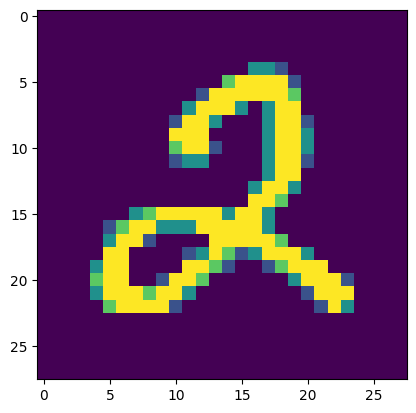

In [2]:
import matplotlib.pyplot as plt

train_image, train_label =  mnist_train[0] # train_image is the input, train_label is the output
train_label = torch.tensor([train_label]) # we convert the output (int) in tensor so we can apply tensor operations ont it


# minimum, maximum, mean value
print(f"minimum of input data {train_image.min()}, maximum: {train_image.max()}, mean: {train_image.mean()}")

# shape an dvalue of input and output
print(f"INPUT INFORMATIONS\n Shape: {train_image.shape}, Value: {train_image}")
print(f"OUTPUT INFORMATIONS\n Shape: {train_label.shape}, Value: {train_label}")

# Input image plot
image_np = train_image.permute(1, 2, 0).numpy()
plt.imshow(image_np) # use cmap="gray" if we want it black and white
plt.show()

####

#### Model


In [3]:
import torch.nn as nn
import torch.nn.functional as F

class MNISTLabelling(nn.Module):

    
    def __init__(self, num_inputs, num_hidden, num_outputs):
        super().__init__()
        
        # Initialize the modules we need to build the network
        self.relu = nn.ReLU()
        self.linear1 = nn.Linear(num_inputs, num_hidden)
        self.linear2 = nn.Linear(num_hidden, num_hidden)
        self.linear3 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        # recompute the imgae info to a vector to be passed to linear
        x = torch.flatten(x, start_dim=1)
        
        # Perform the calculation of the model to determine the prediction
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.relu(x)
        x = self.linear3(x)
        return x

In [4]:

# we want to know the input size
input_size = train_image.numel()

# initialize hidden size
hidden_sizes = [16, 32, 64]

models = {}
for size in hidden_sizes:
    models[f"model{size}"] = MNISTLabelling(num_inputs=input_size, num_hidden=size, num_outputs=10) # predicts score btw 0 and 9

# Printing a module shows all its submodules
print(models)


{'model16': MNISTLabelling(
  (relu): ReLU()
  (linear1): Linear(in_features=784, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=16, bias=True)
  (linear3): Linear(in_features=16, out_features=10, bias=True)
), 'model32': MNISTLabelling(
  (relu): ReLU()
  (linear1): Linear(in_features=784, out_features=32, bias=True)
  (linear2): Linear(in_features=32, out_features=32, bias=True)
  (linear3): Linear(in_features=32, out_features=10, bias=True)
), 'model64': MNISTLabelling(
  (relu): ReLU()
  (linear1): Linear(in_features=784, out_features=64, bias=True)
  (linear2): Linear(in_features=64, out_features=64, bias=True)
  (linear3): Linear(in_features=64, out_features=10, bias=True)
)}


Push model to device (according to tuto)

In [5]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
for model in models.values():
    model.to(device)


#### Create dataloader 
  
We want to use Adam optimizer with a learning rate of 10−3.

In [6]:
import torch.utils.data as data

train_data_loader = data.DataLoader(mnist_train, batch_size=512, shuffle=True)

#### Define optimizer  
  
We want to use Adam optimizer with a learning rate of 10−3.

In [7]:
optimizers = {}
for name, model in models.items():
    optimizers[name] = torch.optim.Adam(model.parameters(), lr=0.001)

#### Loss module

In [8]:
loss_module = nn.CrossEntropyLoss()

#### Train the model

In [9]:
from tqdm.notebook import tqdm
import numpy as np

def train_model(model, optimizer, data_loader, loss_module, num_epochs=100):
    # Set model to train mode
    model.train()
    losses = []
    # Training loop
    for epoch in tqdm(range(num_epochs)):
        for data_inputs, data_labels in data_loader:

            ## Step 1: Move input data to device (only strictly necessary if we use GPU)
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            ## Step 2: Run the model on the input data
            preds = model(data_inputs)

            ## Step 3: Calculate the loss
            loss = loss_module(preds, data_labels)
            losses.append(loss.item())

            ## Step 4: Perform backpropagation
            # Before calculating the gradients, we need to ensure that they are all zero.
            # The gradients would not be overwritten, but actually added to the existing ones.
            optimizer.zero_grad()
            # Perform backpropagation
            loss.backward()

            ## Step 5: Update the parameters
            optimizer.step()
    return np.mean(losses)

state_dict = {}
train_losses = []
for name,  model in models.items():
    loss = train_model(model, optimizers[name], train_data_loader, loss_module, 20) # we fix the number of epochs to 20 according to the task
    state_dict[name] = model.state_dict()
    train_losses.append(loss)


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

#### Validation


In [10]:
# validation data

valid_data_loader = data.DataLoader(mnist_val, batch_size=512) # don't shuffle for validation and test loader

In [11]:
def eval_model(model, data_loader):
    model.eval() # Set model to eval mode

    losses = []
    with torch.no_grad(): # Deactivate gradients for the following code
        for data_inputs, data_labels in data_loader:

            # Determine prediction of model on dev set
            data_inputs, data_labels = data_inputs.to(device), data_labels.to(device)
            preds = model(data_inputs)

            # loss
            loss = loss_module(preds, data_labels)
            losses.append(loss.item())
    
    return np.mean(losses)
            
eval_losses = []
for model in models.values():
    loss = eval_model(model, valid_data_loader) # we fix the number of epochs to 20 according to the task
    eval_losses.append(loss)


#### Results

We want to compare the training and validation losses for the following hidden layer size: 16, 32, and 64. For that, we create a plot that shows the final training and validation loss for each hidden layer size vs. the number of model parameters.

In [12]:
params = []
for model in models.values():
    params.append(sum(p.numel() for p in model.parameters()))

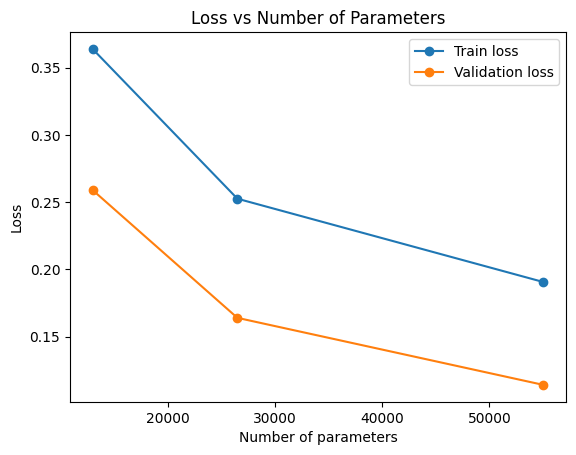

In [13]:
import matplotlib.pyplot as plt

plt.plot(params, train_losses, marker='o', label='Train loss')
plt.plot(params, eval_losses, marker='o', label='Validation loss')

plt.xlabel("Number of parameters")
plt.ylabel("Loss")
plt.title("Loss vs Number of Parameters")
plt.legend()

plt.show()

## 3.1.2 Convolutional Neural Networks


#### Goal

We want to  implement a convolutional neural network (CNN) in PyTorch using the same dataset as before (MNIST)

#### Model + Training

In [14]:
cnn_train_data_loader = data.DataLoader(mnist_train, batch_size=512, shuffle=True)
cnn_eval_data_loader = data.DataLoader(mnist_val, batch_size=512)

class CNNMNistLabelling(nn.Module):

    
    def __init__(self):
        super().__init__()
        
        # Initialize the modules we need to build the network
        self.relu = nn.ReLU()
        self.conv1 = nn.Conv2d(1, 32, 3, 1, 1) # in_channel (grey or RGB), nb of filter, filter size, stride
        self.conv2 = nn.Conv2d(32, 64, 3, 1, 1) # in_channel (grey or RGB), nb of filter, filter size, stride
        self.maxpool = nn.MaxPool2d(2,2)
        self.adaptive_avg_pool = nn.AdaptiveAvgPool2d((1,1)) # transforms a 64x7x7 to 64x1x1 using the mean value
        self.linear1 = nn.Linear(64, 64)
        self.linear3 = nn.Linear(64, 10) # 64 after conv2 and 10 is the ouput range

    def forward(self, x):


        # convolution 1
        x = self.conv1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # convulotion 2
        x = self.conv2(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # fully connected layers
        x = self.adaptive_avg_pool(x) # transformed to (64, 1, 1) -> we need (64)
        x = x.squeeze(-1).squeeze(-1) # remove dimensions of 1
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear3(x)

        return x

In [15]:


model_cnn = CNNMNistLabelling()
model_cnn.to(device)

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# train
train_loss = train_model(model_cnn, optimizer, cnn_train_data_loader, loss_module, 20)

# evaluation
eval_losse = eval_model(model, cnn_eval_data_loader)

# prints
print(f"train loss: {train_loss}, eval loss: {eval_losse}\n")

  0%|          | 0/20 [00:00<?, ?it/s]

train loss: 2.309206940446581, eval loss: 0.11401505395770073



We find an eval loss approximatively equal to training loss, and still inferior, which indicates our model is not overfitting.

#### Training and validation loss comparaison

In [16]:
# total param number
total_param_nb = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_param_nb}\n")

# parameters per layer
for name, param in model.named_parameters():
    print(f"{name}: {param.numel()}\n")

Total parameters: 55050

linear1.weight: 50176

linear1.bias: 64

linear2.weight: 4096

linear2.bias: 64

linear3.weight: 640

linear3.bias: 10



#### How to make it better ?
add more (convolutionnal)  layers
increase kernel size
increase kernel_size ?


## 3.1.3 Convolutional AutoEncoder

Auto-encoder is a part of self-supervised-learning usign a predictive approach during the training. We want to change the output activating function since the problem has changed. It is not a classification problem but a regression problem, that's why the MSE is used as loss module.

#### Training

In [17]:
import torch.utils.data as data
from tqdm.notebook import tqdm


train_data_loader = data.DataLoader(mnist_train, batch_size=512, shuffle=True)
eval_data_loader = data.DataLoader(mnist_test, batch_size=512)

loss_module = nn.MSELoss()


class AutoEncoder(nn.Module):

    
    def __init__(self):
        super().__init__()
        
        # Initialize the modules we need to build the network

        # encoder func
        self.relu = nn.ReLU()
        self.conv1 = nn.Conv2d(1, 32, 3, 1, 1) # in_channel (grey or RGB), nb of filter, filter size, stride
        self.conv2 = nn.Conv2d(32, 64, 3, 1, 1) # , nb of filter, filter size, stride
        self.maxpool = nn.MaxPool2d(2,2)
        self.adaptive_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear1 = nn.Linear(64, 64)
        self.linear2 = nn.Linear(64, 10) # 64 after conv2 and 10 is the ouput range
        
        # decoder func
        self.linear3 = nn.Linear(10, 64)
        self.linearreshape = nn.Linear(64,64*7*7) # we choose de same dimension as the final encoder one
        self.convt1 = nn.ConvTranspose2d(64, 32, 3, 2, 1, 1)
        self.convt2 = nn.ConvTranspose2d(32, 16, 3, 2, 1, 1)
        self.convt3 = nn.ConvTranspose2d(16, 1, 3, 1, 1) # 16 x28x28 -> we found our initial image dimensions


    def encode(self, x):
        # convolution 1
        x = self.conv1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # convulotion 2
        x = self.conv2(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # fully connected layers
        x = self.adaptive_avg_pool(x)
        x = x.squeeze(-1).squeeze(-1)
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)

        return x
    
    def decode(self,x):
        x = self.linear3(x)
        x = self.relu(x)
        x = self.linearreshape(x) # list of 64 nb -> creating list of 64*7*7 creating
        x = x.view(-1, 64, 7, 7) # from 28/2 ->/2 = 7 enlarging

        x = self.convt1(x)
        x = self.relu(x)
        x = self.convt2(x)
        x = self.relu(x)
        x = self.convt3(x)

        # use tanh as output fonction 
        x = torch.tanh(x) 

        return x



    def forward(self, x):

        x = self.encode(x)
        x = self.decode(x)

        return x
    

auto_encoder = AutoEncoder()
auto_encoder.to(device)

def train_model_autoencoder(model, optimizer, data_loader, loss_module, num_epochs=20):
    model.train()
    losses = []
    for epoch in tqdm(range(num_epochs)):
        for data_inputs, _ in data_loader: 

            data_inputs = data_inputs.to(device)
            preds = model(data_inputs)

            loss = loss_module(preds, data_inputs)
            losses.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return np.mean(losses)

#optimizer
optimizer = torch.optim.Adam(auto_encoder.parameters(), lr=0.001)
train_loss = train_model_autoencoder(auto_encoder, optimizer, train_data_loader, loss_module, 20)

state_dict = auto_encoder.state_dict()
torch.save(state_dict, "autoencoder.tar")




  0%|          | 0/20 [00:00<?, ?it/s]

#### Visualization

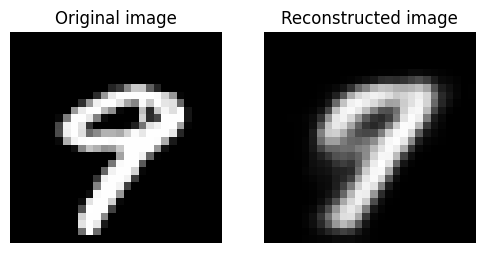

In [22]:
input_image, _ = mnist_test[9] # random image pick
input_image = input_image.unsqueeze(0).to(device)

auto_encoder.eval()
# disable gradient in non training mode
with torch.no_grad():
    reconstructed = auto_encoder(input_image)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(input_image[0].cpu().squeeze(), cmap='gray')
plt.title('Original image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed[0].cpu().squeeze(), cmap='gray')
plt.title('Reconstructed image')
plt.axis('off')

plt.show()